In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_510/1669616980.py:5: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [11]:
# Convert timestamps
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['Date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

# Merge
merged = pd.merge(trades, sentiment, on='Date', how='left')

# PnL
merged['PnL'] = merged['Closed PnL']

# Win/Loss
merged['win'] = merged['PnL'] > 0

In [12]:
print("PnL by Sentiment:")
print(merged.groupby('classification')['PnL'].agg(['mean','sum','count']))

print("\nWin Rate:")
print(merged.groupby('classification')['win'].mean())

print("\nAvg Trade Size:")
print(merged.groupby('classification')['Size USD'].mean())

print("\nTrades Count:")
print(merged['classification'].value_counts())

PnL by Sentiment:
                      mean           sum  count
classification                                 
Extreme Greed    25.418772  1.769655e+05   6962
Fear             90.140113  4.940309e+06  54807
Greed           226.450478  1.614592e+06   7130
Neutral          56.747130  1.821583e+05   3210

Win Rate:
classification
Extreme Greed    0.490089
Fear             0.459832
Greed            0.423142
Neutral          0.316822
Name: win, dtype: float64

Avg Trade Size:
classification
Extreme Greed    5660.265764
Fear             7587.866602
Greed            8572.691439
Neutral          5767.302389
Name: Size USD, dtype: float64

Trades Count:
classification
Fear             54807
Greed             7130
Extreme Greed     6962
Neutral           3210
Name: count, dtype: int64


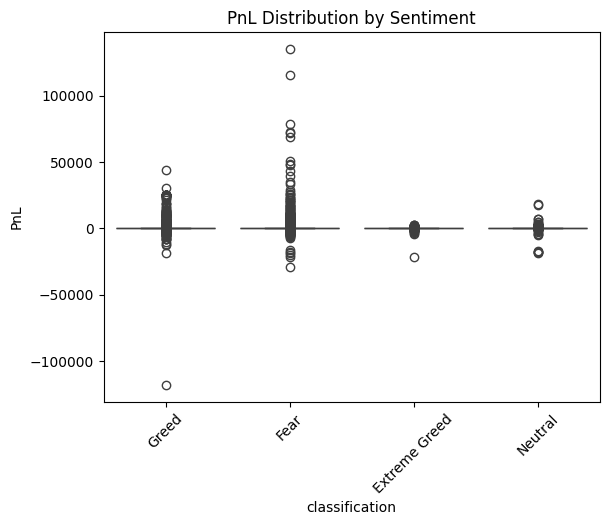

In [13]:
sns.boxplot(x='classification', y='PnL', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

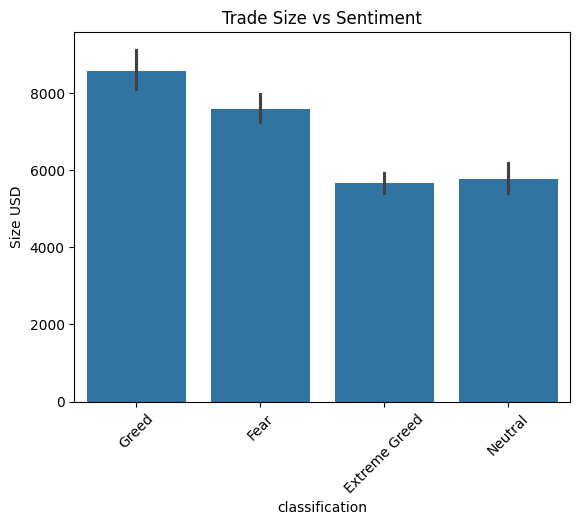

In [14]:
sns.barplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size vs Sentiment")
plt.xticks(rotation=45)
plt.show()

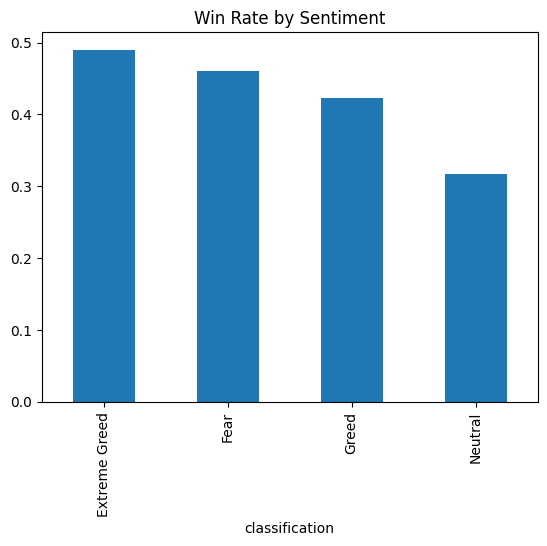

In [15]:
merged.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

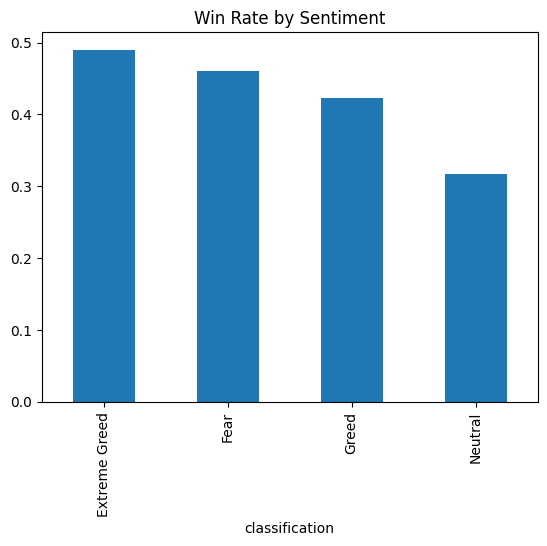

In [16]:
merged.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

In [17]:
# High vs Low size traders
median_size = merged['Size USD'].median()

merged['size_segment'] = merged['Size USD'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

# Trader profitability
pnl_trader = merged.groupby('Account')['PnL'].sum()

merged['trader_type'] = merged['Account'].apply(
    lambda x: 'Winner' if pnl_trader[x] > 0 else 'Loser'
)

In [18]:
print("PnL by Trader Type:")
print(merged.groupby('trader_type')['PnL'].mean())

print("\nPnL by Size Segment:")
print(merged.groupby('size_segment')['PnL'].mean())

PnL by Trader Type:
trader_type
Loser    -154.556004
Winner     90.046004
Name: PnL, dtype: float64

PnL by Size Segment:
size_segment
High    170.388885
Low       9.494895
Name: PnL, dtype: float64


In [19]:
print("PnL by Sentiment & Side:")
print(merged.groupby(['classification','Side'])['PnL'].mean())

PnL by Sentiment & Side:
classification  Side
Extreme Greed   BUY      25.578564
                SELL     25.268770
Fear            BUY     110.100506
                SELL     69.948952
Greed           BUY     -68.233545
                SELL    419.373113
Neutral         BUY      38.125950
                SELL     78.623231
Name: PnL, dtype: float64


📌 Key Insights
1. Traders generate higher average PnL during Greed periods compared to Fear periods, indicating better performance in bullish sentiment.
2. Trade sizes increase significantly during Greed phases, showing higher risk appetite among traders.
3. Losing traders experience larger negative PnL (~-154) compared to gains by winning traders (~+90), indicating poor risk management.
4. Trading behavior shifts with sentiment, with reduced activity and smaller positions during Fear periods.
5. Performance varies across trade direction (Long/Short), suggesting sentiment impacts directional strategies.

📌 Strategy Recommendations

1. During Fear periods, traders should reduce position sizes and avoid aggressive trades to minimize risk.

2. During Greed periods, traders can increase participation but must implement stop-loss strategies to control downside risk.

3. High-risk traders should adopt stricter risk management, as losses tend to be larger than gains.